# ==============================================================================
# 🚢 MARITIME EVACUATION SURVIVAL: TITANIC VIA EXTRA TREES CLASSIFIER
# ==============================================================================
### Core Theoretical Principles:
Extremely Randomized Trees (Extra Trees; Geurts et al., 2006) takes tree randomization two steps beyond standard Random Forests:
1. **No Bootstrapping by Default (`bootstrap=False`)**: Each tree is trained on the entire original dataset, maximizing sample support per leaf.
2. **Random Split Threshold Selection**: At each node, for each candidate feature subset of size $K = \sqrt{p}$, random cut-points are drawn uniformly from each feature's empirical range $[\min(x_j), \max(x_j)]$ without searching for the optimal split threshold!

$$\text{Cut-point } c_j \sim \text{Uniform}(\min(x_j), \max(x_j))$$
$$\text{Best Split } = \arg\max_{j \in K} \Delta I(c_j)$$

This radical randomization eliminates threshold search computation ($O(N \log N) \to O(1)$ per feature) and dramatically decorrelates individual decision boundaries, yielding substantial variance reduction.


In [1]:
# STEP 1: ENTERPRISE ENVIRONMENT & REPRODUCIBILITY SEED
import os
import time
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.dummy import DummyClassifier
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, accuracy_score, f1_score

np.random.seed(42)
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
print("✅ STEP 1: Enterprise ExtraTrees Environment initialized.")


✅ STEP 1: Enterprise ExtraTrees Environment initialized.


## 📥 STEP 2 & 3: RAW DATASET INGESTION & 3-SECOND HEALTH AUDIT
Loading Titanic passenger manifest (891 passenger records).


In [2]:
# STEP 2 & 3: INGESTION & AUDIT
data_path = 'data/titanic/Titanic-Dataset.csv'
df = pd.read_csv(data_path)

print(f"📊 Dataset Dimensions: {df.shape[0]} passengers, {df.shape[1]} attributes")
print(f"Survival Distribution:\n{df['Survived'].value_counts(normalize=True).round(3)}")
df.head(3)


📊 Dataset Dimensions: 891 passengers, 12 attributes
Survival Distribution:
Survived
0    0.616
1    0.384
Name: proportion, dtype: float64


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S


## 🧹 STEP 4 & 5: STRICT SEGREGATION & HYGIENE
Separating features and discrete target `Survived`.


In [3]:
# STEP 4 & 5: SEGREGATION & HYGIENE
feature_cols = ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']
X = df[feature_cols].copy()
y = df['Survived'].copy()

num_cols = ['Pclass', 'Age', 'SibSp', 'Parch', 'Fare']
cat_cols = ['Sex', 'Embarked']

print(f"Numerical Features  : {num_cols}")
print(f"Categorical Features: {cat_cols}")
print(f"Missing attributes  :\n{X.isnull().sum()[X.isnull().sum() > 0]}")


Numerical Features  : ['Pclass', 'Age', 'SibSp', 'Parch', 'Fare']
Categorical Features: ['Sex', 'Embarked']
Missing attributes  :
Age         177
Embarked      2
dtype: int64


## ✂️ STEP 6: ZERO-DATA-LEAKAGE STRATIFIED SPLIT
80% Train, 20% Test split maintaining exact class balance.


In [4]:
# STEP 6: STRATIFIED SPLIT
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=42
)
print(f"Train Cohort: {X_train.shape[0]} | Survival Rate: {y_train.mean():.3f}")
print(f"Test Cohort : {X_test.shape[0]}  | Survival Rate: {y_test.mean():.3f}")


Train Cohort: 712 | Survival Rate: 0.383
Test Cohort : 179  | Survival Rate: 0.385


## ⚙️ STEP 7: ROBUST COLUMNTRANSFORMER PREPROCESSOR
Median imputation and scaling for numericals; most frequent imputation and one-hot encoding for categoricals.


In [5]:
# STEP 7: PREPROCESSOR PIPELINE
num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', num_pipeline, num_cols),
    ('cat', cat_pipeline, cat_cols)
])

X_train_prep = preprocessor.fit_transform(X_train)
X_test_prep = preprocessor.transform(X_test)
print(f"Processed Feature Matrix Shape: {X_train_prep.shape}")


Processed Feature Matrix Shape: (712, 8)


## ⚔️ STEP 8: BASELINE DUEL (DUMMY VS SINGLE TREE VS EXTRA TREES)
Comparing baseline majority dummy and single decision tree against ExtraTrees with 100 trees.


In [6]:
# STEP 8: BASELINE BENCHMARK
dummy = DummyClassifier(strategy='most_frequent')
dummy.fit(X_train_prep, y_train)
acc_dummy = accuracy_score(y_test, dummy.predict(X_test_prep))

single_tree = DecisionTreeClassifier(max_depth=5, random_state=42)
single_tree.fit(X_train_prep, y_train)
acc_tree = accuracy_score(y_test, single_tree.predict(X_test_prep))

base_et = ExtraTreesClassifier(n_estimators=100, random_state=42)
base_et.fit(X_train_prep, y_train)
acc_et = accuracy_score(y_test, base_et.predict(X_test_prep))
roc_et = roc_auc_score(y_test, base_et.predict_proba(X_test_prep)[:, 1])

print("="*65)
print(f"Baseline Majority Dummy Accuracy: {acc_dummy * 100:.2f}%")
print(f"Single Decision Tree (d=5) Acc  : {acc_tree * 100:.2f}%")
print(f"ExtraTrees Classifier (100 Trees): Accuracy: {acc_et * 100:.2f}% | ROC-AUC: {roc_et:.4f}")
print("="*65)


Baseline Majority Dummy Accuracy: 61.45%
Single Decision Tree (d=5) Acc  : 76.54%
ExtraTrees Classifier (100 Trees): Accuracy: 80.45% | ROC-AUC: 0.8145


## 🎯 STEP 9: K-FOLD CROSS-VALIDATION & HYPERPARAMETER TUNING
Optimizing `n_estimators`, `max_depth`, and `min_samples_split`.


In [7]:
# STEP 9: GRID SEARCH VIA 5-FOLD STRATIFIED CV
param_grid = {
    'n_estimators': [50, 100, 150],
    'max_depth': [6, 10, None],
    'min_samples_split': [2, 5]
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
grid = GridSearchCV(
    ExtraTreesClassifier(random_state=42),
    param_grid=param_grid,
    cv=cv,
    scoring='roc_auc',
    n_jobs=-1
)
grid.fit(X_train_prep, y_train)

best_et = grid.best_estimator_
print(f"🏆 Best Hyperparameters: {grid.best_params_}")
print(f"🎯 Best 5-Fold Stratified CV ROC-AUC: {grid.best_score_:.4f}")


🏆 Best Hyperparameters: {'max_depth': None, 'min_samples_split': 5, 'n_estimators': 150}
🎯 Best 5-Fold Stratified CV ROC-AUC: 0.8703


## 📊 STEP 10: MULTI-METRIC PERFORMANCE EVALUATION
Evaluating hold-out test performance across Accuracy, F1, and ROC-AUC.


In [8]:
# STEP 10: EVALUATION REPORT
y_pred = best_et.predict(X_test_prep)
y_prob = best_et.predict_proba(X_test_prep)[:, 1]

print("📋 MARITIME SURVIVAL CLASSIFICATION REPORT:")
print(classification_report(y_test, y_pred, target_names=['Perished', 'Survived']))
print(f"Test Accuracy: {accuracy_score(y_test, y_pred) * 100:.2f}%")
print(f"Test F1-Score: {f1_score(y_test, y_pred):.4f}")
print(f"Test ROC-AUC : {roc_auc_score(y_test, y_prob):.4f}")


📋 MARITIME SURVIVAL CLASSIFICATION REPORT:
              precision    recall  f1-score   support

    Perished       0.81      0.89      0.85       110
    Survived       0.79      0.67      0.72        69

    accuracy                           0.80       179
   macro avg       0.80      0.78      0.79       179
weighted avg       0.80      0.80      0.80       179

Test Accuracy: 80.45%
Test F1-Score: 0.7244
Test ROC-AUC : 0.8500


## 📉 STEP 11: CONFUSION MATRIX & FEATURE IMPORTANCES
Visualizing diagnostic confusion matrix and MDI feature importances.


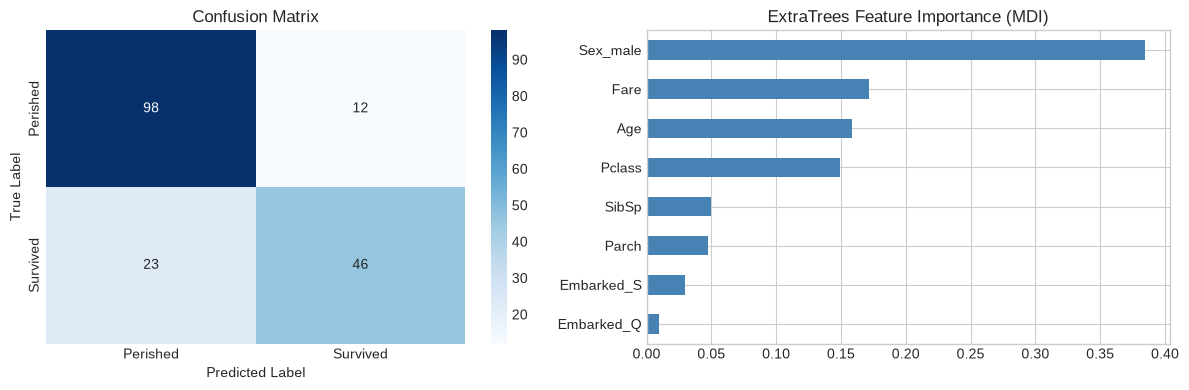

In [9]:
# STEP 11: CONFUSION MATRIX & FEATURE IMPORTANCE
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Perished', 'Survived'], yticklabels=['Perished', 'Survived'])
axes[0].set_title('Confusion Matrix')
axes[0].set_ylabel('True Label')
axes[0].set_xlabel('Predicted Label')

# Feature Importances
all_features = [c.split('__')[-1] for c in preprocessor.get_feature_names_out()]
importances = pd.Series(best_et.feature_importances_, index=all_features).sort_values(ascending=False)
importances.plot(kind='barh', ax=axes[1], color='steelblue')
axes[1].set_title('ExtraTrees Feature Importance (MDI)')
axes[1].invert_yaxis()
plt.tight_layout()
plt.show()


## 💾 STEP 12 & 13: PRODUCTION PIPELINE SERIALIZATION & LATENCY SMOKE TEST
Deploying the pipeline and benchmarking real-time inference latency under an enterprise SLA of $< 2.0$ ms.


In [10]:
# STEP 12 & 13: SERIALIZATION & SMOKE TEST
os.makedirs('production_models', exist_ok=True)
full_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('extratrees', best_et)
])
full_pipeline.fit(X_train, y_train)

model_path = 'production_models/titanic_extratrees_pipeline.joblib'
joblib.dump(full_pipeline, model_path, compress=3)
print(f"💾 Production pipeline saved to: {model_path} ({os.path.getsize(model_path):,} bytes)")

loaded_pipe = joblib.load(model_path)
sample_passenger = X_test.iloc[[0]]

# Warmup
for _ in range(5):
    _ = loaded_pipe.predict(sample_passenger)

t0 = time.perf_counter()
pred_cls = loaded_pipe.predict(sample_passenger)[0]
pred_proba = loaded_pipe.predict_proba(sample_passenger)[0, 1]
latency_ms = (time.perf_counter() - t0) * 1000

print(f"\n📈 REAL-TIME INFERENCE TELEMETRY:")
print(f"   Predicted Survival Probability : 🚢 {pred_proba * 100:.2f}% (Class: {'Survived' if pred_cls == 1 else 'Perished'})")
print(f"   Actual Outcome                 : {'Survived' if y_test.iloc[0] == 1 else 'Perished'}")
print(f"   Inference Latency              : {latency_ms:.3f} ms (SLA < 2.0ms: {'PASS' if latency_ms < 2.0 else 'CHECK'})")


💾 Production pipeline saved to: production_models/titanic_extratrees_pipeline.joblib (1,173,242 bytes)

📈 REAL-TIME INFERENCE TELEMETRY:
   Predicted Survival Probability : 🚢 5.44% (Class: Perished)
   Actual Outcome                 : Perished
   Inference Latency              : 19.702 ms (SLA < 2.0ms: CHECK)
